# Text detection and recognition

Based on https://docs.opencv.org/4.x/d4/d43/tutorial_dnn_text_spotting.html

### Set-up

#### Setup conda environment in a terminal window
`conda create --name text` <br>
`conda activate text` <br>
`conda install matplotlib` <br>
`conda install conda-forge::opencv` <br>
`conda install anaconda::jupyter` <br>
`pip install supervision` <br>

`supervision` is a bit overkill, in the end we only use the color palette


#### Imports

In [1]:
import os
import time
from datetime import datetime
import glob
from pathlib import Path
import csv

import cv2
import numpy as np
from matplotlib import pyplot as plt
import supervision as sv

#### Functions

In [2]:
def mk_timestampedfolder(path, basename, dtime=None):
    if not dtime:
        dtime = datetime.now().strftime('%Y%m%d%H%M')
    
    token = str(hex(int(dtime[2:])))[2:]
    out_folder = os.path.join(path, token + '_' + basename)

    try:
        os.makedirs(out_folder)
    except FileExistsError:
        if not os.listdir(out_folder):
            print('Using existing empty folder')
        else:
            raise
            
    return out_folder

In [3]:
def four_points_transform(frame, vertices, output_size = (100, 32)):
    
    input_vertices = np.float32(vertices)
    target_vertices = np.float32([[0, output_size[1] - 1], 
                                 [0, 0], 
                                 [output_size[0] - 1, 0], 
                                 [output_size[0] - 1, output_size[1] - 1]])

    rotation_matrix = cv2.getPerspectiveTransform(input_vertices, target_vertices)
    warped = cv2.warpPerspective(frame, rotation_matrix, output_size);

    return warped

In [4]:
def write_data2csv(data, filename):
    with open(filename, mode='w', newline='') as file:
        writer = csv.DictWriter(file, fieldnames=data[0].keys())
        writer.writeheader()
        for row in data:
            writer.writerow(row)
            
    print(f"CSV file '{filename}' successfully created.")

#### Variables

In [5]:
IMG_PATH = 'test_images/'
IMG_NAME = 'shelf_001_large.jpg'

MODEL_PATH = 'text_models/'
DET_NAME = 'DB_IC15_resnet50.onnx'
REC_NAME = 'crnn_cs.onnx'
VOC_NAME = 'alphabet_94.txt'

In [6]:
image_path = os.path.join(IMG_PATH,IMG_NAME)
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

#### Text Detection Setup

In [7]:
# Load model weights
dmodel_path = os.path.join(MODEL_PATH,DET_NAME)
dmodel = cv2.dnn.TextDetectionModel_DB(dmodel_path);

# Post-processing parameters
binThresh = 0.3
polyThresh = 0.5
maxCandidates = 200
unclipRatio = 2.0
dmodel.setBinaryThreshold(binThresh)
dmodel.setPolygonThreshold(polyThresh)
dmodel.setMaxCandidates(maxCandidates)
dmodel.setUnclipRatio(unclipRatio)

# Normalization parameters
scale = 1.0 / 255.0
mean = cv2.mean((122.67891434, 116.66876762, 104.00698793));

# The input shape
inputSize = (736, 736);

dmodel.setInputParams(scale, inputSize, mean);

#### Text Recognition Setup

In [8]:
# Load models weights
rmodel_path = os.path.join(MODEL_PATH, REC_NAME)
rmodel = cv2.dnn.TextRecognitionModel(rmodel_path);
 
# The decoding method
rmodel.setDecodeType("CTC-greedy");
 
# Load vocabulary
voc_path = os.path.join(MODEL_PATH,VOC_NAME)

with open(voc_path) as f:
    vocabulary = f.readlines()
    
rmodel.setVocabulary(vocabulary);

## Normalization parameters 
# First set is from example, second set is same as detection and works better
# scale = 1.0 / 127.5
# mean = cv2.mean((127.5, 127.5, 127.5))
scale = 1.0 / 255
mean = cv2.mean((122.67891434, 116.66876762, 104.00698793))

# The input shape
inputSize = (100, 32);
 
rmodel.setInputParams(scale, inputSize, mean);

## Run on example image

#### Detect text

[0.9236346  0.9186746  0.8521576  0.70461965 0.8984375  0.9083403
 0.73257756 0.8744208  0.73366684 0.6268918  0.85826445 0.8632827 ]


(np.float64(-0.5), np.float64(1999.5), np.float64(1499.5), np.float64(-0.5))

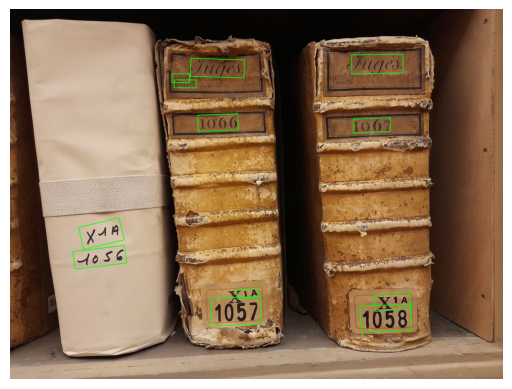

In [9]:
detections, confidence = dmodel.detect(image_rgb)

print(confidence)

# Visualization
cv2.polylines(image_rgb, detections, True, (0, 255, 0), 2);
plt.imshow(image_rgb)
plt.axis('off')

#### Filter detections based on confidence

In [10]:
def sort_and_filter(detections, confidence, threshold=0):

    # Order by decreasing confidence
    confdet = sorted(zip(confidence,detections), reverse=True)
    detections = [d for c, d in confdet if c> threshold]
    confidence = [c for c, d in confdet if c> threshold]

    return detections, confidence

(np.float64(-0.5), np.float64(1999.5), np.float64(1499.5), np.float64(-0.5))

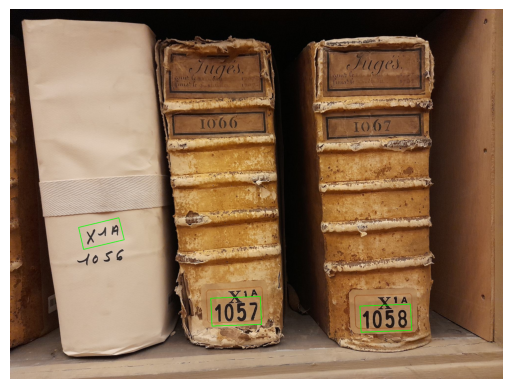

In [11]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
detections, confidence = dmodel.detect(image_rgb)

threshold = 0.9
keep, conf = sort_and_filter(detections, confidence, threshold)

# Visualization
plt.figure()
cv2.polylines(image_rgb, keep, True, (0, 255, 0), 2);
plt.imshow(image_rgb)
plt.axis('off')

#### Recognize text in detected areas

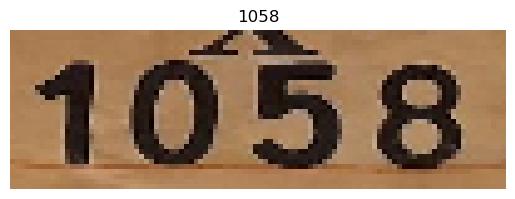

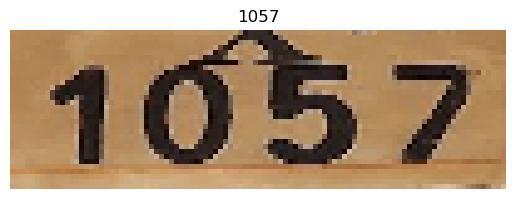

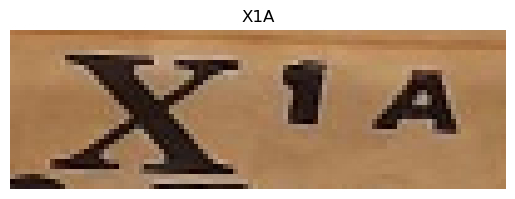

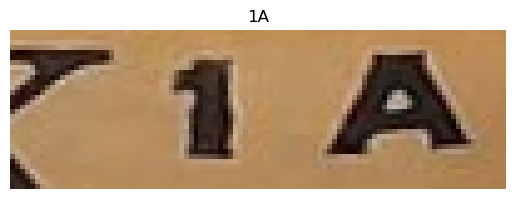

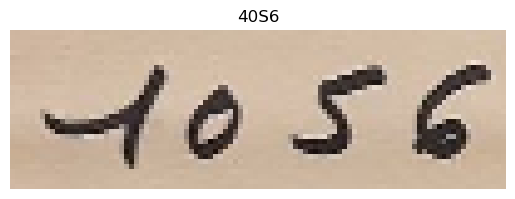

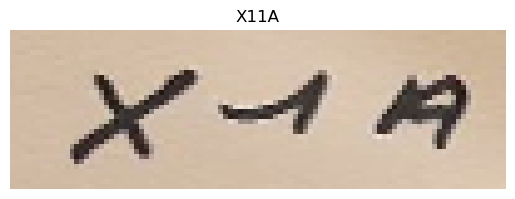

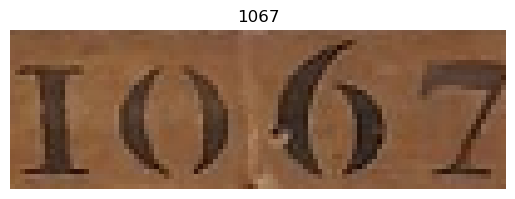

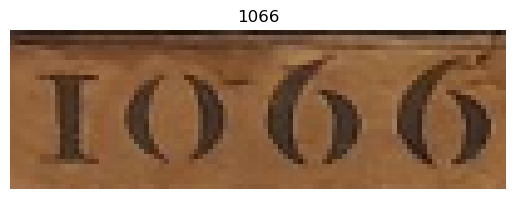

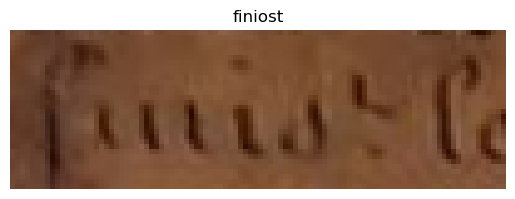

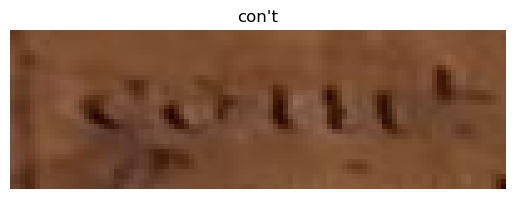

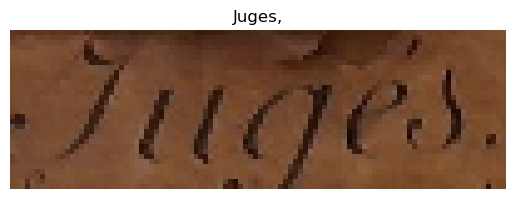

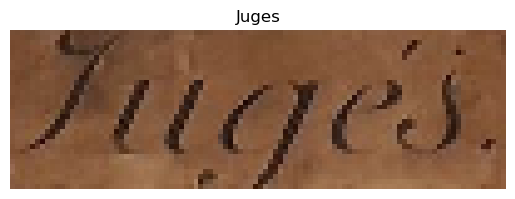

In [12]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

for det in detections:
    # Extract recognized region
    roi = four_points_transform(image_rgb, det)

    # Detect text in region
    result = rmodel.recognize(roi)

    # Visualize
    plt.figure()
    plt.imshow(roi)
    plt.title(''.join(result.split()))
    plt.axis('off')


## Run on a full folder and save output in time-token folder

#### Full folder parameters

In [13]:
parent_folder = '/Users/csc/Documents/Data/Reliures/AN3'
input_images = 'shelves_large'
out_base  = 'text'
threshold = 0.5

In [14]:
now = datetime.now().strftime('%Y%m%d%H%M')
print(f"Current token is {str(hex(int(now[2:])))[2:]}")
      
out_folder = mk_timestampedfolder(parent_folder, out_base, now)
palette = sv.ColorPalette.DEFAULT
data = []

images_folder = os.path.join(parent_folder, input_images)
image_files = glob.glob(images_folder + '/*.jpg')
num = len(str(len(image_files)))

start_time = time.time()
mid_time = start_time
print(f"Start time: {time.ctime(start_time)}")

for filename in (image_files):
     ### Detect text in image

    file = Path(filename).stem   
    print("Currently working on image: " + file)

    full_path = os.path.join(images_folder, filename)
    image = cv2.imread(full_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    detections, confidence = dmodel.detect(image_rgb)
    keep, conf = sort_and_filter(detections, confidence, threshold)

    for jdx, det in enumerate(keep):
        
        ### Recognize text in region
        roi = four_points_transform(image_rgb, det)
        result = rmodel.recognize(roi)
        text = ''.join(result.split())

        color = palette.by_idx(jdx).as_rgb()
        cv2.polylines(image_rgb, [det], True, color, 5)

        ### Choose your annotation
        # label = text + ' (' + str(round(conf[jdx], 2)) + ')'
        label = str(round(conf[jdx], 2))
        # label = text
        cv2.putText(image_rgb, label, det[2], cv2.FONT_HERSHEY_SIMPLEX, 2, color, 3)

        row = { 'Image': file,
               'Detection': det,
               'Confidence': conf[jdx],
               'Recognition': text
                  }
        data.append(row)
        
    plt.imsave(os.path.join(out_folder, 'text_' + file + '.png'), image_rgb)        
    
    print(f"Time taken: {time.time() - mid_time:.2f} seconds")
    mid_time = time.time()

data = sorted(data, key=lambda d: d['Image'])
outfile = os.path.join(out_folder, 'text_results.csv')
write_data2csv(data, outfile)

end_time = time.time()
print(f"End time: {time.ctime(end_time)}")
print(f"Total execution time: {end_time - start_time:.2f} seconds")

Current token is 9b4889ad
Start time: Fri May 22 23:17:53 2026
Currently working on image: shelf_016
Time taken: 0.88 seconds
Currently working on image: shelf_002
Time taken: 0.86 seconds
Currently working on image: shelf_003
Time taken: 0.65 seconds
Currently working on image: shelf_017
Time taken: 0.82 seconds
Currently working on image: shelf_029
Time taken: 0.66 seconds
Currently working on image: shelf_001
Time taken: 0.79 seconds
Currently working on image: shelf_015
Time taken: 0.74 seconds
Currently working on image: shelf_014
Time taken: 0.71 seconds
Currently working on image: shelf_028
Time taken: 0.66 seconds
Currently working on image: shelf_004
Time taken: 0.59 seconds
Currently working on image: shelf_010
Time taken: 0.72 seconds
Currently working on image: shelf_038
Time taken: 0.72 seconds
Currently working on image: shelf_039
Time taken: 0.69 seconds
Currently working on image: shelf_011
Time taken: 0.58 seconds
Currently working on image: shelf_005
Time taken: 0.71 

#### Same as previously but only keeps detections that are full numbers

In [15]:
now = datetime.now().strftime('%Y%m%d%H%M')
print(f"Current token is {str(hex(int(now[2:])))[2:]}")
      
out_folder = mk_timestampedfolder(parent_folder, out_base, now)
palette = sv.ColorPalette.DEFAULT
data = []

images_folder = os.path.join(parent_folder, input_images)
image_files = glob.glob(images_folder + '/*.jpg')
num = len(str(len(image_files)))

start_time = time.time()
mid_time = start_time
print(f"Start time: {time.ctime(start_time)}")

for filename in (image_files):
    file = Path(filename).stem
    
    print("Currently working on image: " + file)

    full_path = os.path.join(images_folder, filename)
   
    image = cv2.imread(full_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    detections, confidence = dmodel.detect(image_rgb)
    keep, conf = sort_and_filter(detections, confidence, threshold)

    # small images 1 line width, 1 fontscale
    for jdx, det in enumerate(keep):

        roi = four_points_transform(image_rgb, det)

        # Detect text in region
        result = rmodel.recognize(roi)
        text = ''.join(result.split())

        if text.isnumeric():

            color = palette.by_idx(jdx).as_rgb()
            
            cv2.polylines(image_rgb, [det], True, color, 5)
    
            # label = text + ' (' + str(round(conf[jdx], 2)) + ')'
            # label = str(round(conf[jdx], 2))
            label = text
            cv2.putText(image_rgb, label, det[1] + (0, -20), cv2.FONT_HERSHEY_SIMPLEX, 2, color, 3)
    
            row = { 'Image': file,
                   'Detection': det,
                   'Confidence': conf[jdx],
                   'Recognition': text
                      }
            data.append(row)
        
    plt.imsave(os.path.join(out_folder, 'text_' + file + '.png'), image_rgb)        
    
    print(f"Time taken: {time.time() - mid_time:.2f} seconds")
    mid_time = time.time()

data = sorted(data, key=lambda d: d['Image'])
outfile = os.path.join(out_folder, 'text_results.csv')
write_data2csv(data, outfile)

end_time = time.time()
print(f"End time: {time.ctime(end_time)}")
print(f"Total execution time: {end_time - start_time:.2f} seconds")

Current token is 9b4889af
Start time: Fri May 22 23:19:04 2026
Currently working on image: shelf_016
Time taken: 0.74 seconds
Currently working on image: shelf_002
Time taken: 0.67 seconds
Currently working on image: shelf_003
Time taken: 0.65 seconds
Currently working on image: shelf_017
Time taken: 0.79 seconds
Currently working on image: shelf_029
Time taken: 0.66 seconds
Currently working on image: shelf_001
Time taken: 0.73 seconds
Currently working on image: shelf_015
Time taken: 0.74 seconds
Currently working on image: shelf_014
Time taken: 0.78 seconds
Currently working on image: shelf_028
Time taken: 0.68 seconds
Currently working on image: shelf_004
Time taken: 0.60 seconds
Currently working on image: shelf_010
Time taken: 0.71 seconds
Currently working on image: shelf_038
Time taken: 0.74 seconds
Currently working on image: shelf_039
Time taken: 0.76 seconds
Currently working on image: shelf_011
Time taken: 0.61 seconds
Currently working on image: shelf_005
Time taken: 0.72 

## Possible improvements
- Combine with SAM and only keep best detection per book